<a href="https://colab.research.google.com/github/shristea7/College-Dump/blob/main/AI_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import argparse
import random
import time
import tracemalloc
from collections import deque
from typing import List, Tuple, Optional, Dict, Set
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def is_valid(grid, r, c):
    rows, cols = len(grid), len(grid[0])
    return 0 <= r < rows and 0 <= c < cols and grid[r][c] != '#'

In [ ]:
def generate_grid(rows, cols, wall_prob=0.3):

    grid = []
    for r in range(rows):
        row = []
        for c in range(cols):
            # Randomly choose wall or path
            if random.random() < wall_prob:
                row.append('#')   # wall
            else:
                row.append('.')   # path
        grid.append(row)
    # Place Start and End
    sr, sc = 0, 0
    er, ec = rows - 1, cols - 1
    grid[sr][sc] = 'S'
    grid[er][ec] = 'E'
    return grid

In [ ]:
def bfs(grid):
    rows, cols = len(grid), len(grid[0])
    queue = deque([((0, 0), [(0, 0)])])
    visited = set([(0, 0)])
    explored = []

    nodes_expanded = 0
    max_frontier = 1

    while queue:
        max_frontier = max(max_frontier, len(queue))
        (r, c), path = queue.popleft()
        explored.append((r, c))
        nodes_expanded += 1

        if (r, c) == (rows - 1, cols - 1):
            return path, explored, nodes_expanded, max_frontier

        for dr, dc in [(0,1),(1,0),(0,-1),(-1,0)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < rows and 0 <= nc < cols:
                if grid[nr][nc] == '.' and (nr, nc) not in visited:
                    visited.add((nr, nc))
                    queue.append(((nr, nc), path + [(nr, nc)]))

    return None, explored, nodes_expanded, max_frontier

In [ ]:
def dfs(grid):
    rows, cols = len(grid), len(grid[0])
    stack = [((0, 0), [(0, 0)])]
    visited = set([(0, 0)])
    explored = []

    nodes_expanded = 0
    max_frontier = 1

    while stack:
        max_frontier = max(max_frontier, len(stack))
        (r, c), path = stack.pop()
        explored.append((r, c))
        nodes_expanded += 1

        if (r, c) == (rows - 1, cols - 1):
            return path, explored, nodes_expanded, max_frontier

        for dr, dc in [(0,1),(1,0),(0,-1),(-1,0)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < rows and 0 <= nc < cols:
                if grid[nr][nc] == '.' and (nr, nc) not in visited:
                    visited.add((nr, nc))
                    stack.append(((nr, nc), path + [(nr, nc)]))
    return None, explored, nodes_expanded, max_frontier

In [ ]:
def visualize(grid, explored, path, title):
    rows, cols = len(grid), len(grid[0])
    maze = []
    for r in range(rows):
        row = []
        for c in range(cols):
            if grid[r][c] == '#':
                row.append(0)     # black (wall)
            else:
                row.append(1)     # white (open)
        maze.append(row)
    plt.figure(figsize=(7, 7))
    plt.imshow(maze, cmap="gray")
    for r, c in explored: # Color explored cells
        plt.scatter(c, r, color="blue", s=20)  # BFS explored
    if path:
        for r, c in path:
           plt.scatter(c, r, color="yellow", s=40)
    plt.scatter(0, 0, color="red", s=100)          # Start
    plt.scatter(cols - 1, rows - 1, color="green", s=100)  # End
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.show()


Enter number of rows: 6
Enter number of columns: 6

Generated Maze:
S . # . . .
# . . . # .
. . # # . .
. . . # . #
. . # . . .
# . . # # E


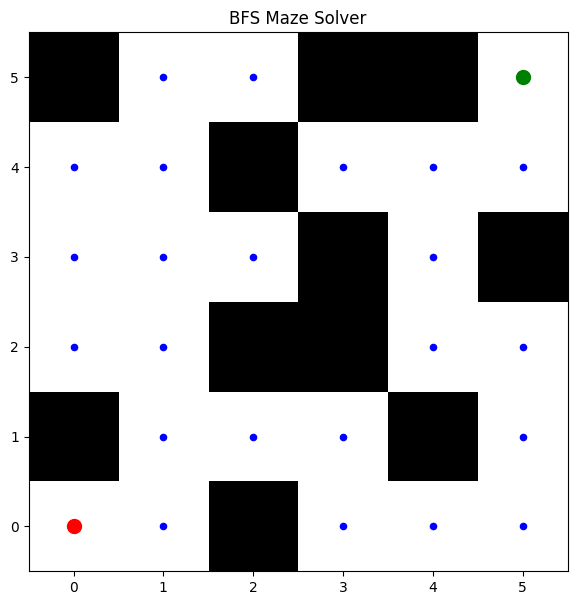

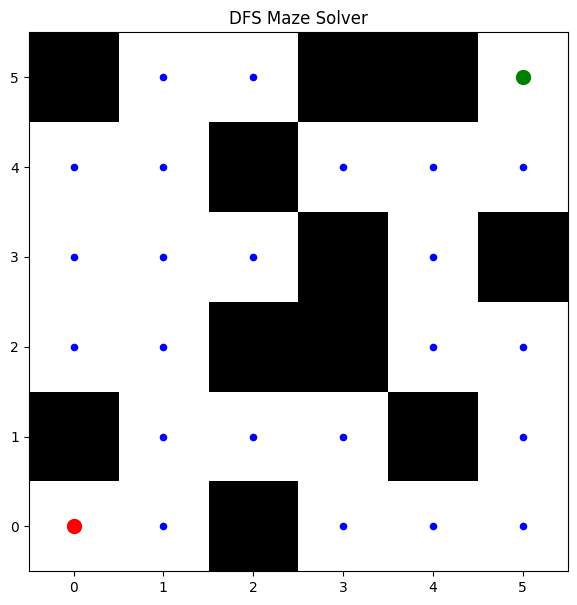


--- BFS RESULT ---
Path length    : No path
Nodes expanded : 24
Memory used    : 5

--- DFS RESULT ---
Path length    : No path
Nodes expanded : 24
Memory used    : 3

--- PRACTICAL COMPARISON ---
No path found by both BFS and DFS. Comparison not applicable.


In [ ]:
rows = int(input("Enter number of rows: "))
cols = int(input("Enter number of columns: "))

grid = generate_grid(rows, cols)

print("\nGenerated Maze:")
for row in grid:
    print(" ".join(row))

# BFS
bfs_path, bfs_explored, bfs_nodes, bfs_mem = bfs(grid)
visualize(grid, bfs_explored, bfs_path, "BFS Maze Solver")

# DFS
dfs_path, dfs_explored, dfs_nodes, dfs_mem = dfs(grid)
visualize(grid, dfs_explored, dfs_path, "DFS Maze Solver")

print("\n--- BFS RESULT ---")
print("Path length    :", len(bfs_path) if bfs_path else "No path")
print("Nodes expanded :", bfs_nodes)
print("Memory used    :", bfs_mem)

print("\n--- DFS RESULT ---")
print("Path length    :", len(dfs_path) if dfs_path else "No path")
print("Nodes expanded :", dfs_nodes)
print("Memory used    :", dfs_mem)

print("\n--- PRACTICAL COMPARISON ---")

if bfs_path is None and dfs_path is None:
    print("No path found by both BFS and DFS. Comparison not applicable.")

elif bfs_path is not None and dfs_path is None:
    print("Only BFS found a path.")

elif bfs_path is None and dfs_path is not None:
    print("Only DFS found a path.")

else:
    print("Shortest path :",
          "BFS" if len(bfs_path) < len(dfs_path) else "DFS")

    print("More memory   :",
          "BFS" if bfs_mem > dfs_mem else "DFS")

    print("More expanded :",
          "BFS" if bfs_nodes > dfs_nodes else "DFS")
